In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.utils.utility import standardizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [2]:
dados = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutos.xlsx')

dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Data           576 non-null    datetime64[us]
 1   Estatistica    576 non-null    str           
 2   COR            573 non-null    float64       
 3   TURB.          573 non-null    float64       
 4   pH             573 non-null    float64       
 5   ALC.           546 non-null    float64       
 6   AC.            546 non-null    float64       
 7   O.C.           555 non-null    float64       
 8   DBO            21 non-null     float64       
 9   O.D.           560 non-null    float64       
 10  Cl             555 non-null    float64       
 11  DUR.           555 non-null    float64       
 12  Fe             555 non-null    float64       
 13  Mn             555 non-null    float64       
 14  N              63 non-null     float64       
 15  P              54 non-null     flo

<>:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\Wary\AppData\Local\Temp\ipykernel_27220\1122716967.py:1: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  dados = pd.read_excel('C:\_Master\programacao\Guilherme-Betta\IC2\data\in\dadosBrutos.xlsx')


In [4]:
colunas_data = [coluna for coluna in dados.columns if str(dados[coluna].dtype).startswith('datetime')]

print(colunas_data)

['Data']


# Geração de visualizações

<Axes: >

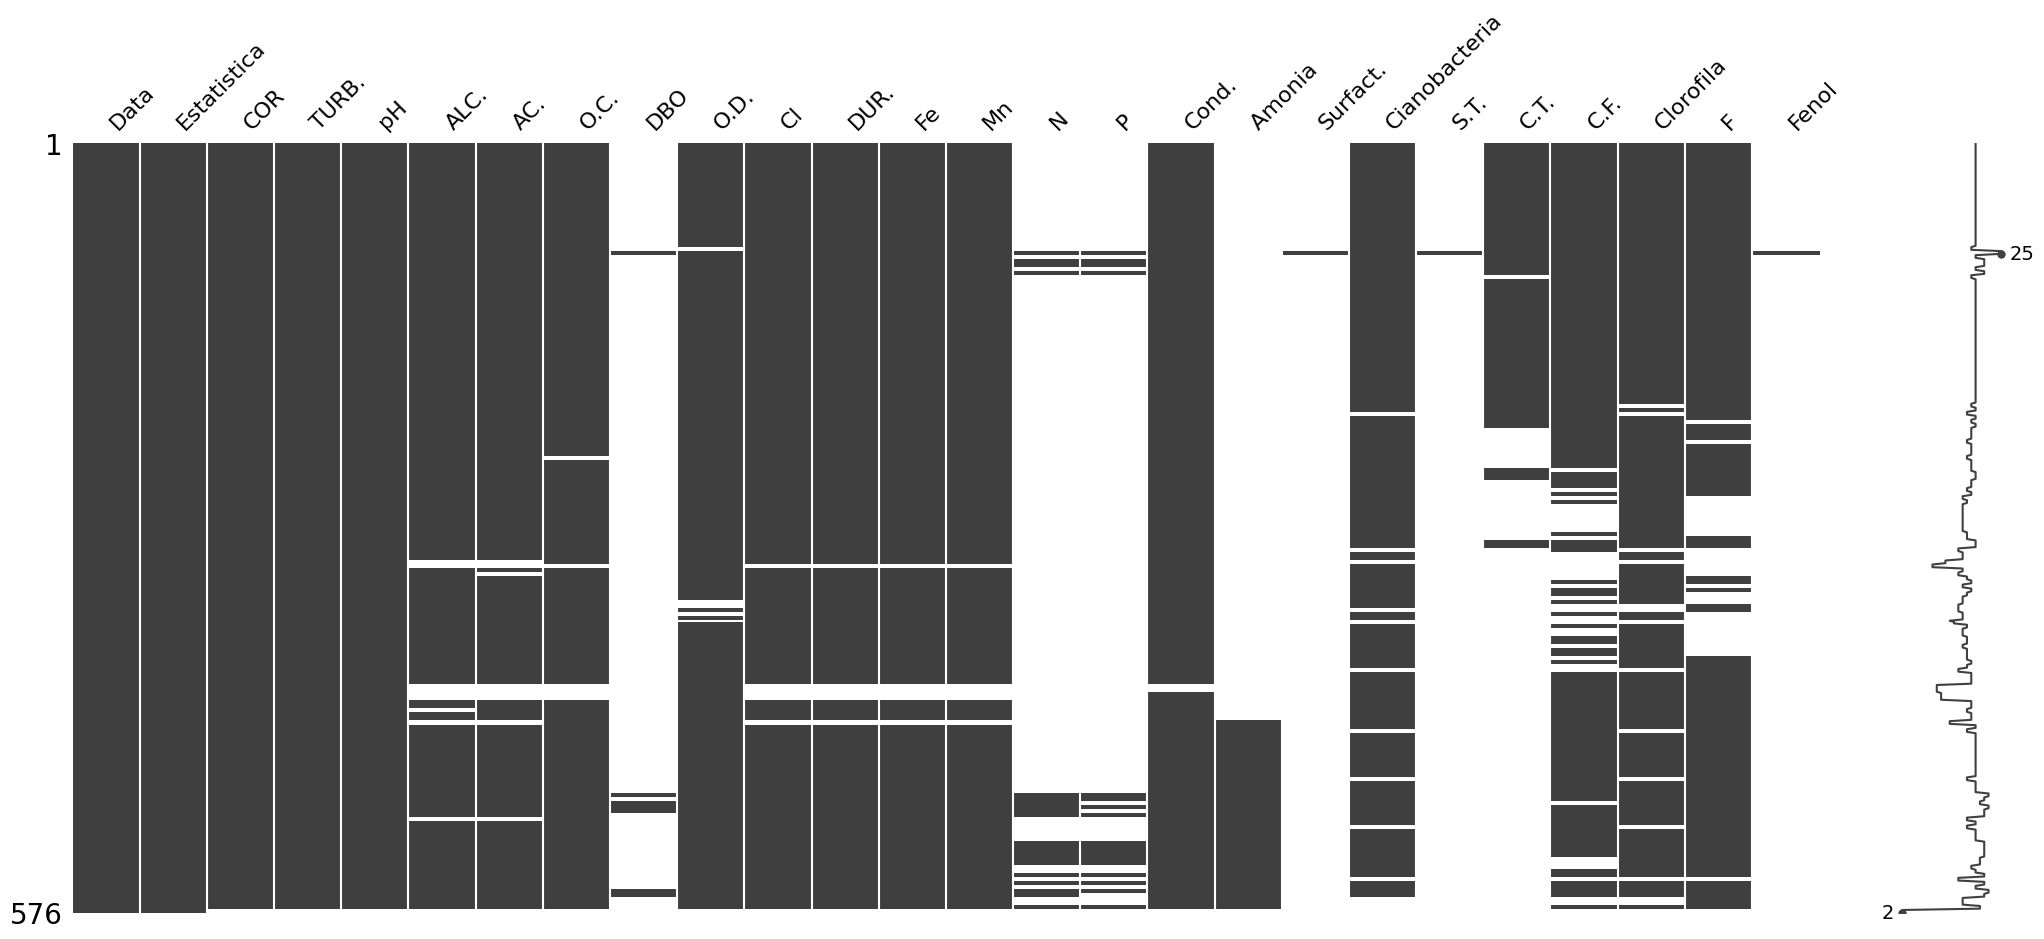

In [5]:
msno.matrix(dados)  # Gera uma matriz representando dados faltantes/coluna

<Axes: >

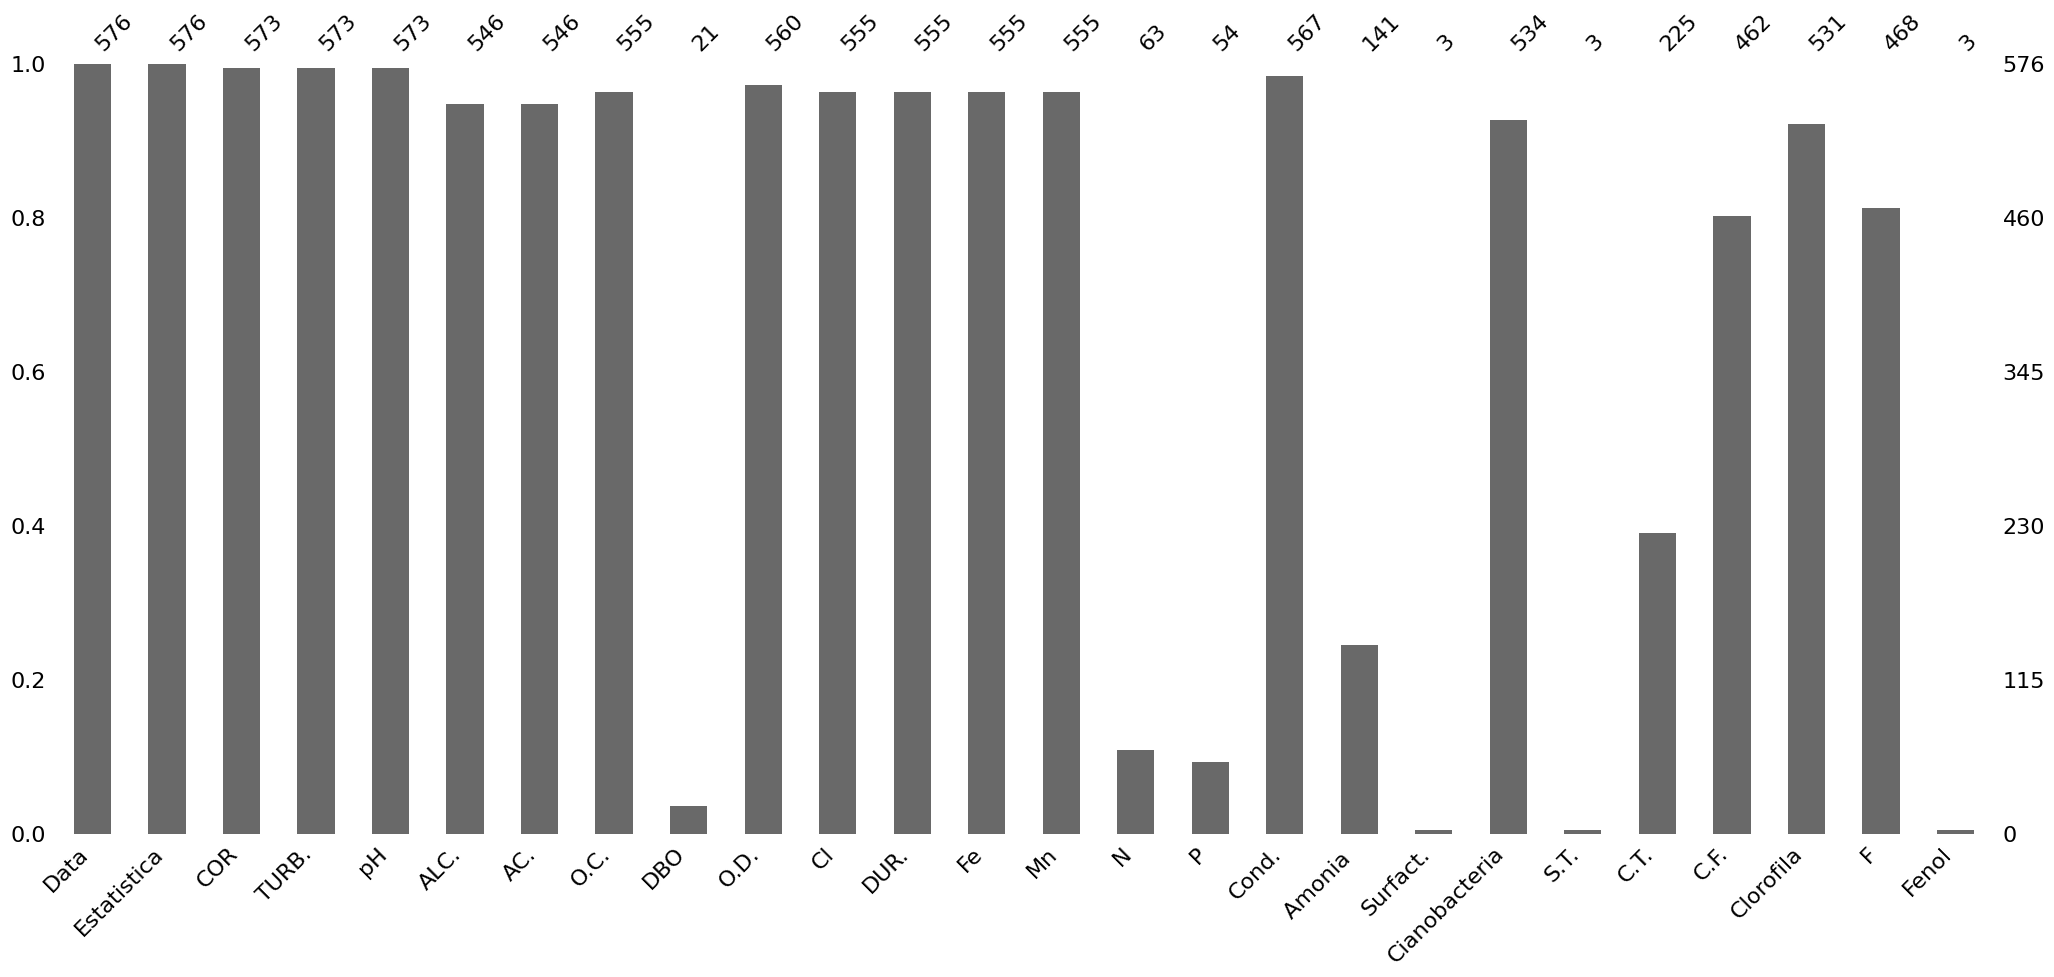

In [6]:
msno.bar(dados) # Gera um gráfico de barras

<Axes: >

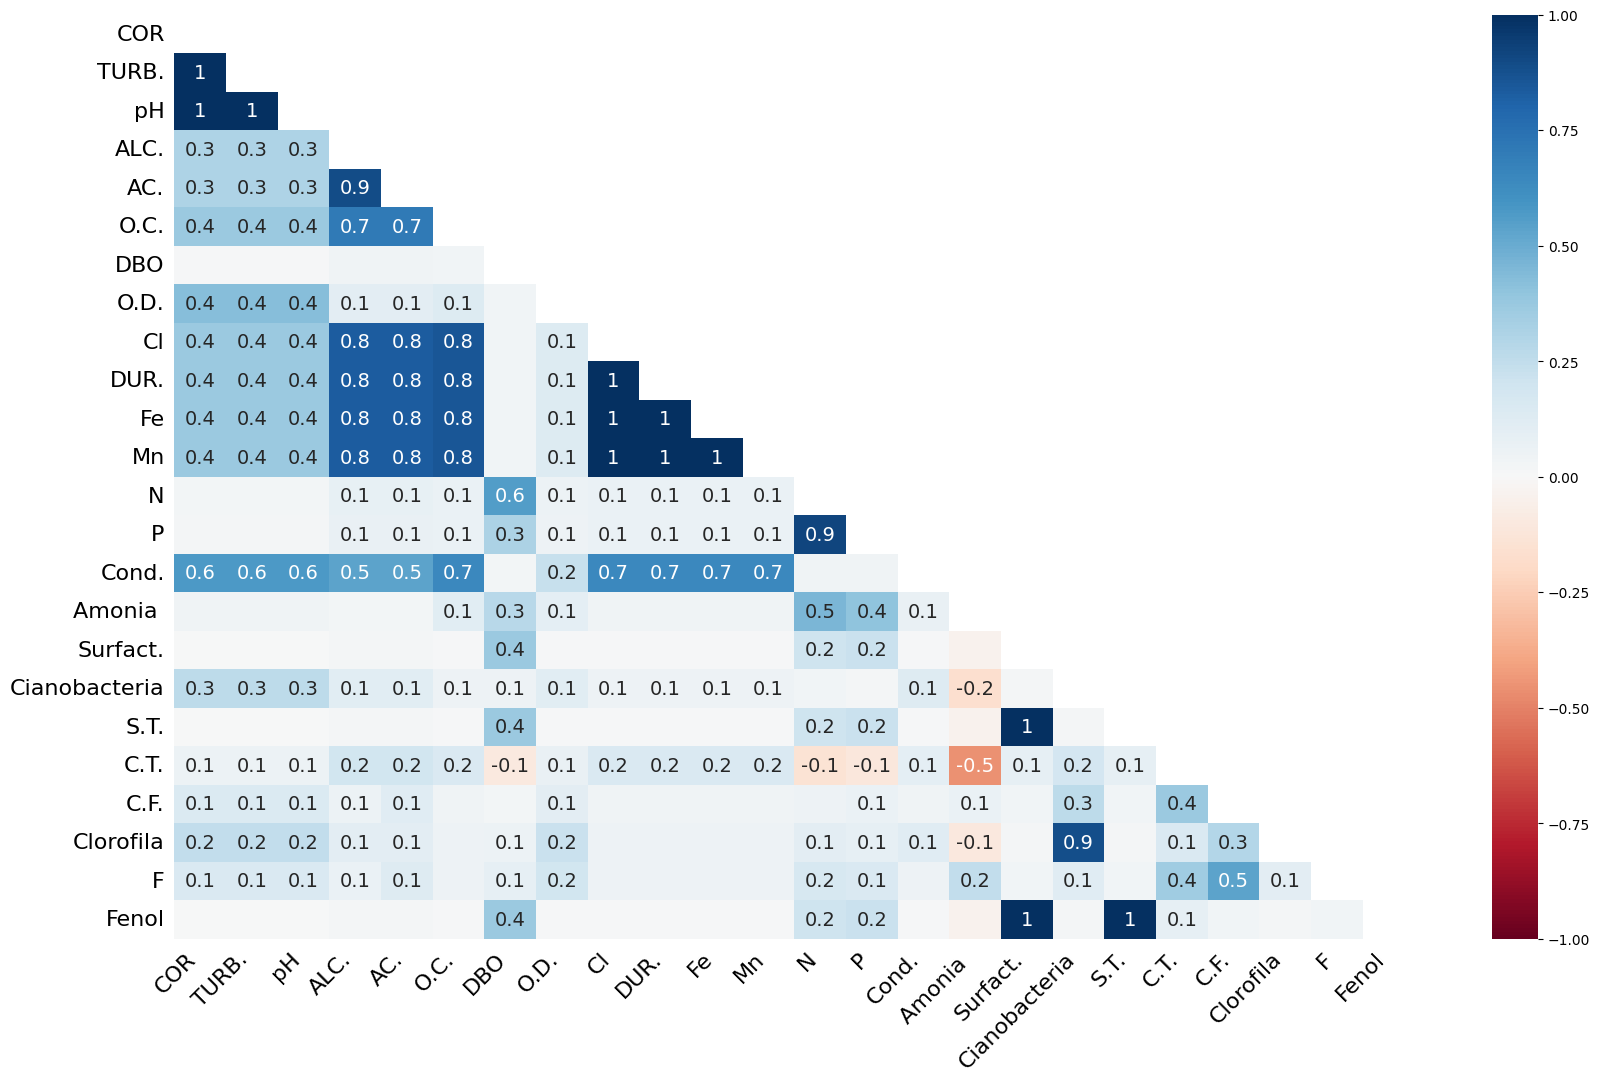

In [7]:
msno.heatmap(dados) # Gera um mapa de calor

<Axes: >

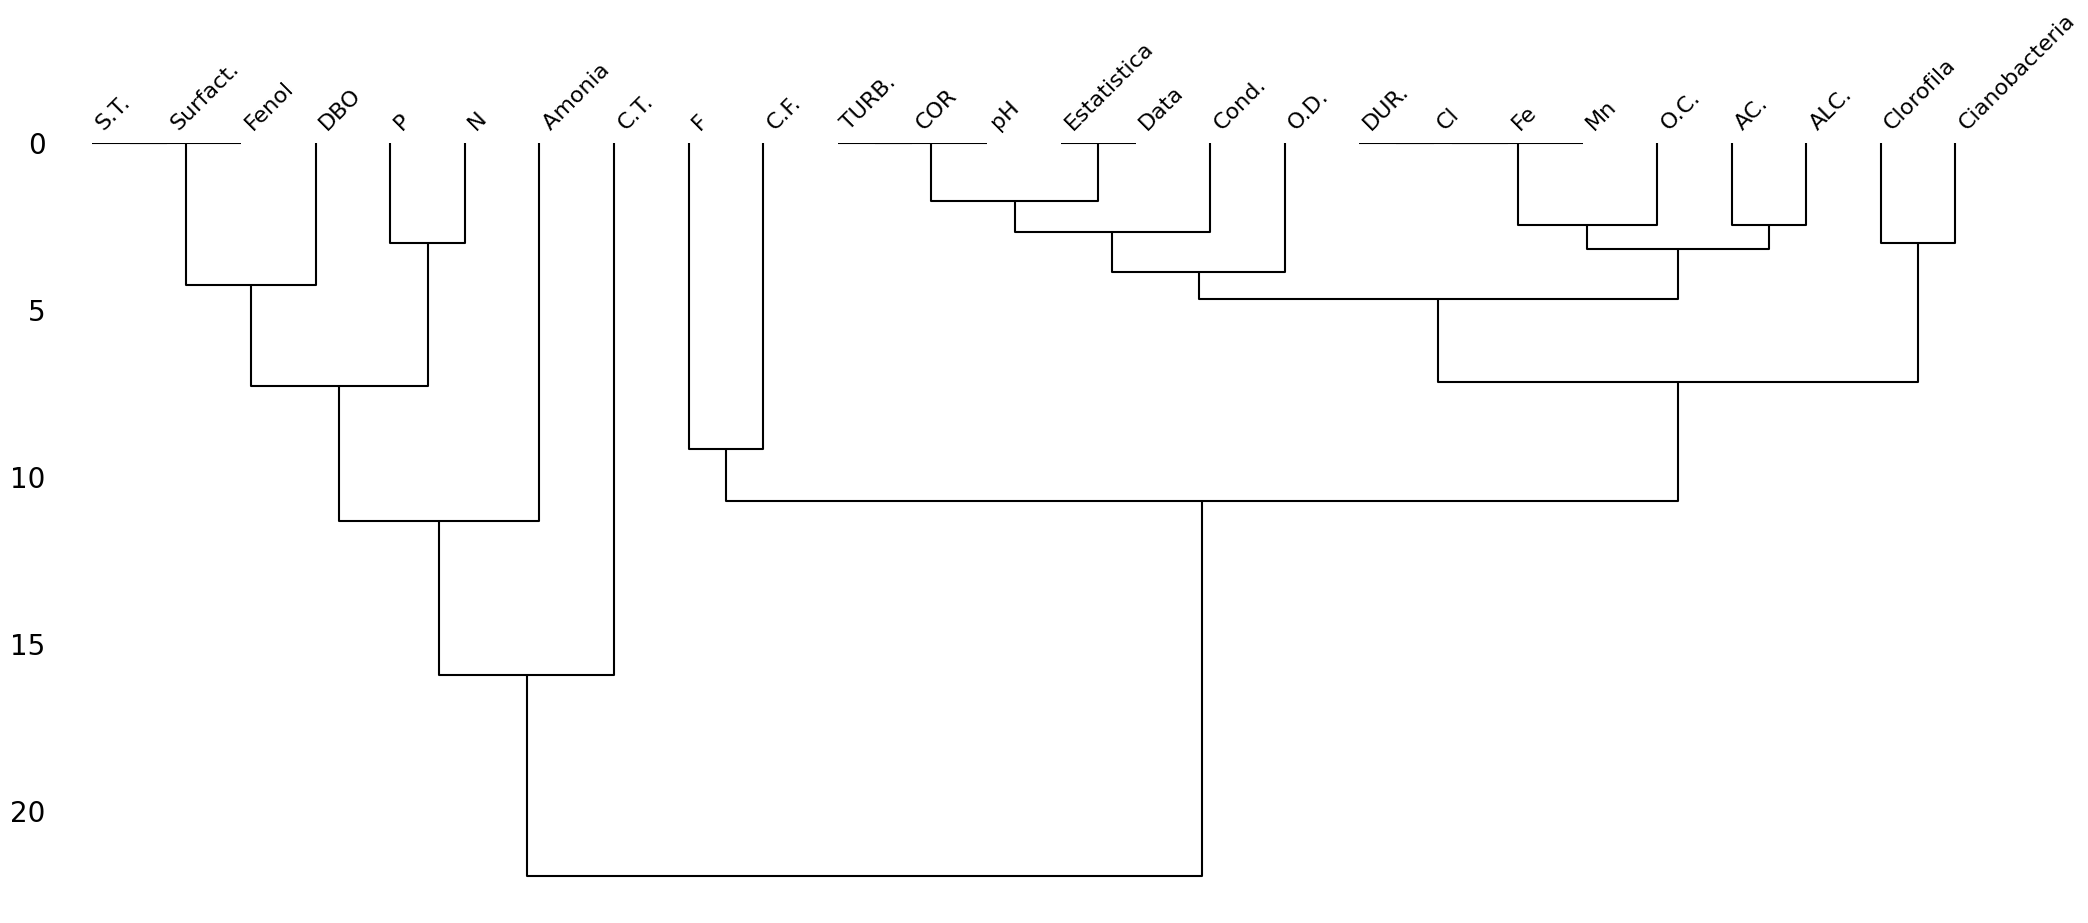

In [8]:
msno.dendrogram(dados)  # Gera um dendograma

In [8]:


# taxa de missing por ano (0 → completo, 1 → tudo faltando)
missing_por_ano = (dados.drop(columns=colunas_data).groupby(dados["Data"].dt.year).apply(lambda x: x.isna().mean()*100))

# transpor para variáveis ficarem no eixo vertical
missing_por_ano = missing_por_ano.T

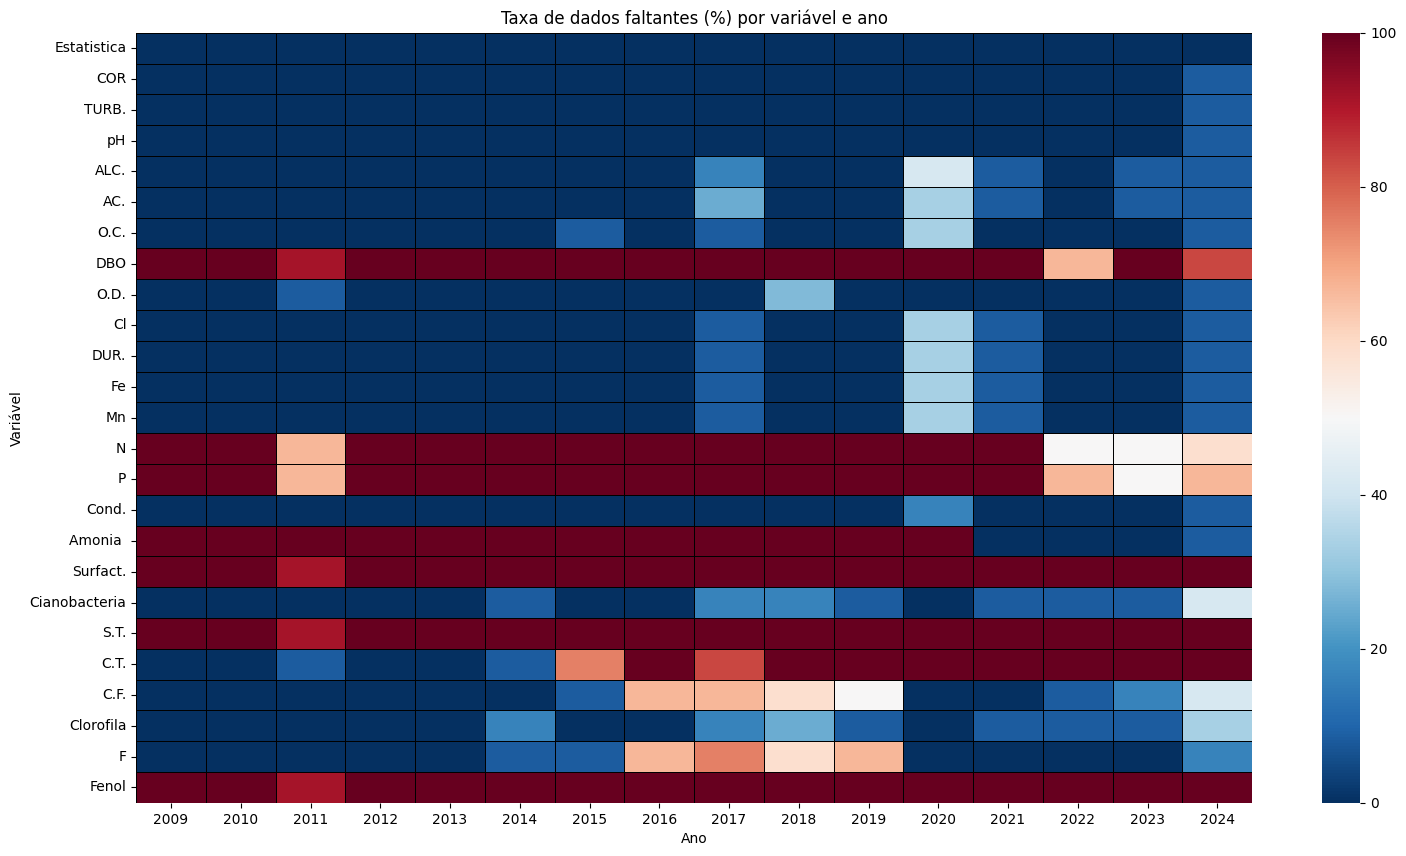

In [9]:
plt.figure(figsize=(18, 10))
sns.heatmap(
    missing_por_ano,
    cmap="RdBu_r",  # azul = completo | vermelho = faltante
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="black"
)

plt.title("Taxa de dados faltantes (%) por variável e ano")
plt.xlabel("Ano")
plt.ylabel("Variável")
plt.show()

In [18]:
missing_meses = (dados.drop(columns=colunas_data)).groupby(dados['Data'].dt.year).apply(lambda x: x.isna().sum())

missing_meses = missing_meses.T


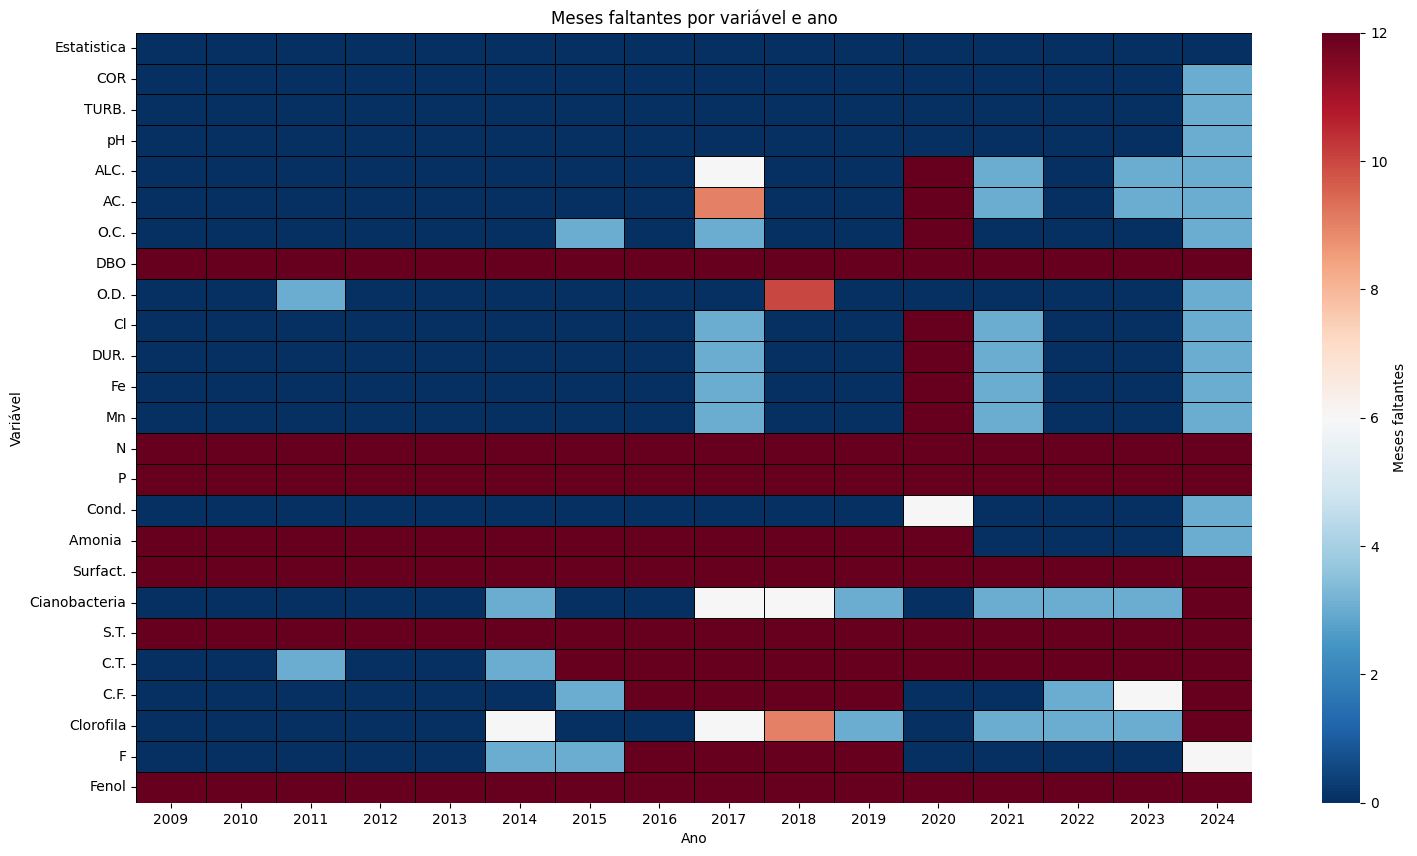

In [20]:

plt.figure(figsize=(18, 10))
sns.heatmap(
    missing_meses,
    cmap="RdBu_r",
    vmin=0,
    vmax=12,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Meses faltantes"}
)

plt.title("Meses faltantes por variável e ano")
plt.xlabel("Ano")
plt.ylabel("Variável")
plt.show()